In [2]:
from sentence_transformers import SentenceTransformer
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
model = SentenceTransformer("clip-ViT-B-32")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

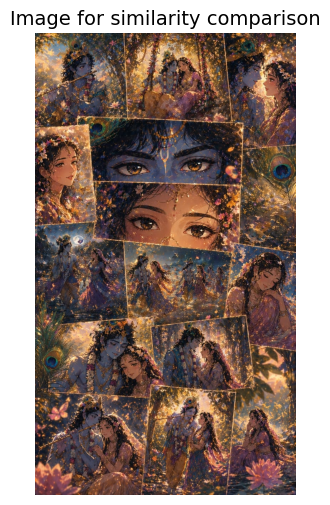

In [3]:
img1 = "/content/3.jpg"
img1 = Image.open(img1)
plt.figure(figsize= (6,6))
plt.imshow(img1)
plt.axis("off")
plt.title("Image for similarity comparison",fontsize=14)
plt.show()

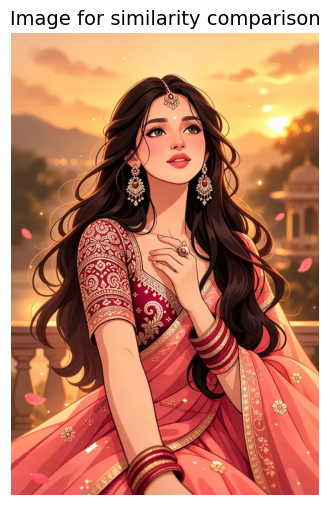

In [4]:
img2 = "/content/4.jpg"
img2 = Image.open(img2)
plt.figure(figsize= (6,6))
plt.imshow(img2)
plt.axis("off")
plt.title("Image for similarity comparison",fontsize=14)
plt.show()

In [5]:
text_description = ["A little girl is reading a book",
                    "The dog is running in the park",
                    "A animated picture of saint"
                    "A man is drinking coffee",
                    "The sun is shining brightly"]

In [6]:
def display_image_and_compare(image_path,text_description):
  # loading image
  img = Image.open(image_path)

  # encode text and image (converting both into numbers)
  text_emb = model.encode(text_description)
  img_emb = model.encode(img)

  # compute similarity score
  similarity_score = np.dot(text_emb,img_emb.T)

  # find the best match
  best_match_index = np.argmax(similarity_score)
  best_match_desc = text_description[best_match_index]

  # print the final output
  print(f"\nbest match for the image is L {best_match_desc} with score of {similarity_score.max()}")
  # display the image
  plt.figure(figsize = (6,6))
  plt.imshow(img)
  plt.axis('off')
  plt.title("Image for similarity comparison",fontsize=14)
  plt.show()


best match for the image is L A animated picture of saintA man is drinking coffee with score of 24.44986343383789


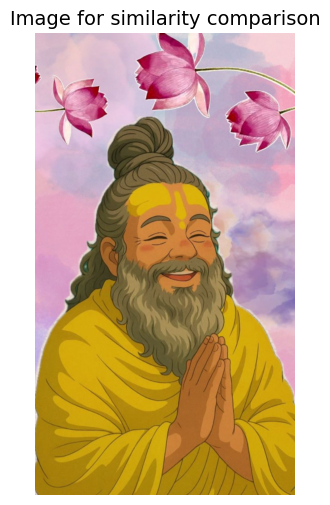

In [7]:
display_image_and_compare("/content/5.jpg",text_description)